In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix


In [ ]:

tumor_markers = ['AFP', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'HE4']
hematological_features = ['BASO#', 'BASO%', 'EO#', 'EO%', 'HCT', 'HGB', 'LYM#', 'LYM%', 'MCH', 'MCV', 'MONO#', 'MONO%', 'MPV', 'NEU', 'PCT', 'PDW', 'PLT', 'RBC', 'RDW']
clinical_features = ['AG', 'Age', 'ALB', 'ALP', 'ALT', 'AST', 'BUN', 'Ca', 'CL', 'CO2CP', 'CREA', 'DBIL', 'GGT', 'GLO', 'GLU.', 'IBIL', 'K', 'Menopause', 'Mg', 'Na', 'PHOS', 'TBIL', 'TP', 'UA']
clin_hem_features = hematological_features + clinical_features
all_features = tumor_markers + clin_hem_features


In [ ]:


file_path = '/kaggle/input/predict-ovarian-cancer/Supplementary data 1.xlsx'
df = pd.read_excel(file_path)
if 'SUBJECT_ID' in df.columns:
    df.drop('SUBJECT_ID', axis=1, inplace=True)

def clean_numeric_columns(df_in, columns):
    df_out = df_in.copy();
    def clean_value(x):
        if pd.isna(x): return np.nan
        if isinstance(x, (int, float)): return float(x)
        if isinstance(x, str):
            cleaned = re.sub(r'\\t|\s+', '', x); 
            try: 
                return float(cleaned)
            except ValueError:
                return np.nan
        return np.nan
    for col in columns: df_out[col] = df_out[col].apply(clean_value).astype(float)
    return df_out

object_columns_to_clean = df[all_features].select_dtypes(include=['object']).columns.tolist()
if object_columns_to_clean:
     print(f"Cleaning object columns: {object_columns_to_clean}")
     df = clean_numeric_columns(df, object_columns_to_clean)


Cleaning object columns: ['AFP', 'CA125', 'CA19-9']


In [ ]:

# Define Imputation function and Distributions 
BIOMARKER_DISTRIBUTIONS = {
   'AFP': {'mean': 5, 'std': 2.5}, 'CA125': {'mean': 17, 'std': 9}, 'CA19-9': {'mean': 18, 'std': 9.5}, 'CA72-4': {'mean': 3.5, 'std': 1.7}, 'HE4': {'mean': 70, 'std': 20},
   'AG': {'mean': 12, 'std': 2}, 'ALB': {'mean': 4.4, 'std': 0.5}, 'ALP': {'mean': 80, 'std': 30}, 'ALT': {'mean': 30, 'std': 12}, 'AST': {'mean': 28, 'std': 10},
   'CO2CP': {'mean': 26, 'std': 1.5}, 'DBIL': {'mean': 0.15, 'std': 0.1}, 'GGT': {'mean': 15, 'std': 7}, 'GLO': {'mean': 2.9, 'std': 0.3}, 'IBIL': { 'mean': 0.5, 'std': 0.2},
   'MPV': { 'mean': 9.5, 'std': 1}, 'NEU': {'mean': 4.75, 'std': 1.5}, 'PCT': {'mean': 0.1, 'std': 0.2}, 'PDW': {'mean': 13, 'std': 2}, 'TBIL': {'mean': 0.75, 'std': 0.3 }, 'TP': { 'mean': 7.15,  'std': 0.5 }
}
def generate_biomarker_imputation(df_in, biomarkers=None, seed=42): 
    imputed_df_out = df_in.copy(); np.random.seed(seed)
    if biomarkers is None: biomarkers = list(BIOMARKER_DISTRIBUTIONS.keys())
    for marker in biomarkers:
        if marker not in imputed_df_out.columns or not imputed_df_out[marker].isna().any(): continue
        dist_params = BIOMARKER_DISTRIBUTIONS[marker]; missing_mask = imputed_df_out[marker].isna(); n_missing = missing_mask.sum()
        impute_values = np.random.normal(loc=dist_params['mean'], scale=dist_params['std'], size=n_missing); impute_values[impute_values < 0] = 0
        imputed_df_out.loc[missing_mask, marker] = impute_values
    return imputed_df_out, {} # Return empty dict for simplicity here

features_to_impute_dist = [f for f in all_features if f in BIOMARKER_DISTRIBUTIONS and df[f].isnull().any()]
df_imputed, _ = generate_biomarker_imputation(df, biomarkers=features_to_impute_dist)


In [7]:

# Impute remaining NaNs in ALL selected features with their respective means
for col in all_features:
   if df_imputed[col].isnull().any():
       mean_val = df_imputed[col].mean()
       df_imputed[col].fillna(mean_val, inplace=True)
print("Imputation complete for all features.")


Imputation complete for all features.


/tmp/ipykernel_31/1744266511.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(mean_val, inplace=True)


In [ ]:

X_all = df_imputed[all_features]
y_all = df_imputed['TYPE']

_, X_test_all, _, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f"Test set shape: {X_test_all.shape}, {y_test.shape}")


Test set shape: (70, 49), (70,)


In [ ]:

rf_model_tm = joblib.load('/kaggle/input/models_v2/scikitlearn/default/1/rf_model_tumor_markers.joblib')
scaler_tm = joblib.load('/kaggle/input/models_v2/scikitlearn/default/1/scaler_tumor_markers.joblib')
print("Tumor Marker model and scaler loaded.")

rf_model_ch = joblib.load('/kaggle/input/models_v2/scikitlearn/default/1/rf_model_clin_hem.joblib')
scaler_ch = joblib.load('/kaggle/input/models_v2/scikitlearn/default/1/scaler_clin_hem.joblib')
print("Clinical/Hematological model and scaler loaded.")


Tumor Marker model and scaler loaded.
Clinical/Hematological model and scaler loaded.


In [ ]:

# Select the correct feature subsets from the overall test set
X_test_tm = X_test_all[tumor_markers]
X_test_ch = X_test_all[clin_hem_features]

# Apply the corresponding loaded scaler to each test subset
X_test_tm_scaled = scaler_tm.transform(X_test_tm)
X_test_ch_scaled = scaler_ch.transform(X_test_ch)
print("Test subsets scaled using loaded scalers.")


Test subsets scaled using loaded scalers.


In [ ]:

# Predict probabilities: shape [n_samples, n_classes] (e.g., [n_samples, 2])
proba_tm = rf_model_tm.predict_proba(X_test_tm_scaled)
proba_ch = rf_model_ch.predict_proba(X_test_ch_scaled)

# Select probability for the positive class (Ovarian Cancer, usually class 1)
proba_pos_tm = proba_tm[:, 1]
proba_pos_ch = proba_ch[:, 1]


In [12]:

# --- Step 7: Fuse Probabilities (Simple Averaging) ---
avg_proba = (proba_pos_tm + proba_pos_ch) / 2.0

# Make final prediction based on threshold (0.5)
fused_pred = (avg_proba > 0.5).astype(int)


In [ ]:

print("\nEvaluating Fused Model (Averaging Probabilities)...")

accuracy_fused = accuracy_score(y_test, fused_pred)
balanced_accuracy_fused = balanced_accuracy_score(y_test, fused_pred)
cm_fused = confusion_matrix(y_test, fused_pred)
report_fused = classification_report(y_test, fused_pred, target_names=['Benign', 'Ovarian Cancer'])

print(f"Fused Model Test Accuracy: {accuracy_fused:.4f}")
print(f"Fused Model Test Balanced Accuracy: {balanced_accuracy_fused:.4f}")
print("\nFused Model Classification Report:\n", report_fused)



Evaluating Fused Model (Averaging Probabilities)...
Fused Model Test Accuracy: 0.9429
Fused Model Test Balanced Accuracy: 0.9420

Fused Model Classification Report:
                 precision    recall  f1-score   support

        Benign       0.97      0.91      0.94        34
Ovarian Cancer       0.92      0.97      0.95        36

      accuracy                           0.94        70
     macro avg       0.94      0.94      0.94        70
  weighted avg       0.94      0.94      0.94        70



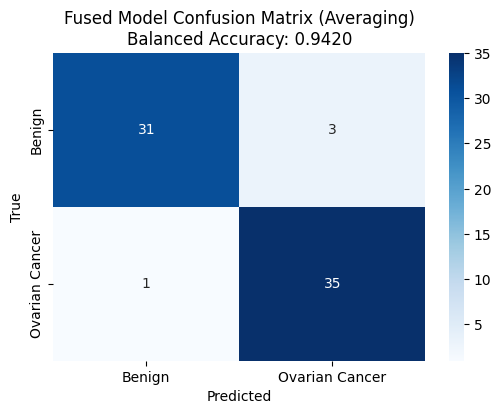

In [14]:

# Plot confusion matrix for fused model
plt.figure(figsize=(6, 4))
sns.heatmap(cm_fused, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Ovarian Cancer'],
            yticklabels=['Benign', 'Ovarian Cancer'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Fused Model Confusion Matrix (Averaging)\nBalanced Accuracy: {balanced_accuracy_fused:.4f}')
plt.show()